# MAE vs MOCO Embeddings

Both **Masked Autoencoders (MAE)** and **Momentum Contrast (MoCo)** are self-supervised learning (SSL) techniques that generate meaningful representations without labeled data. However, they differ significantly in how they learn embeddings and where they perform best.

## MAE (Masked Autoencoder)
- Uses a **reconstruction-based approach**.
- Randomly **masks** parts of an input image and learns to reconstruct the missing regions.
- Uses a **Transformer encoder-decoder** architecture.
- Focuses on **dense feature learning** rather than explicit instance discrimination.
## MoCo (Momentum Contrast)
- Uses a **contrastive learning approach**.
- Encourages **similar images to have close embeddings** while pushing apart embeddings of different images.
- Maintains a momentum encoder that stores a queue of negative samples for stable training.
- Optimized for **discriminative feature learning** (useful for classification)


## Differences in Embeddings
Feature | MAE Embeddings | MoCo Embeddings
--------| -------------- | ---------------
Training Objective | Reconstruction of masked image patches | Constrastive learning via instance discrimination
Feature Type | Dense, high-dimensional | Compact, separable, low-dimensional
Global/Local Features | Learns local features | Learns global features
Linear Probe Performance | Weaker hard to separate classes) | Stronger (better class separability)
Best for | Dense tasks (segmentation) | Classification tasks (Object recongnition)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset

import sys
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from torchsummary import summary

In [2]:
!git clone https://github.com/facebookresearch/mae.git
sys.path.append('mae')
import models_mae

fatal: destination path 'mae' already exists and is not an empty directory.


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Running on a GPU")
else:
    device = torch.device("cpu")
    print("Running on a CPU")

Running on a GPU


## Cifar 10 Dataset Loading

In [4]:
transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Resize(224),
                transforms.Normalize(mean=(0.485, 0.456, 0.406),
                                     std=(0.229, 0.224, 0.225))
            ])

batch_size = 512

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


The following function computes embeddings given a model and input data.

In [10]:
def compute_embeddings_from_dataset(dataset, model, embedding_dim, device, batch_size):
    model = model.to(device=device)
    print(next(model.parameters()).device)  # Should print 'cuda' or 'cpu'
    model = model.eval()
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embeddings = torch.zeros(len(dataset), embedding_dim)
    labels = torch.zeros(len(dataset))
    #with torch.no_grad():
    for idx, batch in enumerate(tqdm.tqdm(dataloader)):
        start = idx * batch_size
        end = min((idx + 1) * batch_size, len(dataset))

        inputs, targets = batch
        embs = model(inputs.to(device))
        embeddings[start:end] = embs
        labels[start:end] = targets
    return embeddings, labels

## Pre-compute MoCo representations
The following two functions download the pre-trained MoCo model and pass it through `compute_embeddings_from_dataset` to generate image embeddings for MoCo.

In [11]:
def prepare_moco(moco_state_dict):
    moco = models.resnet50(weights=None, progress=False)
    # rename moco pre-trained keys
    for k in list(moco_state_dict.keys()):
        # retain only encoder_q up to before the embedding layer
        if k.startswith('module.encoder_q') and not k.startswith('module.encoder_q.fc'):
            # remove prefix
            moco_state_dict[k[len("module.encoder_q."):]] = moco_state_dict[k]
        # delete renamed or unused k
        del moco_state_dict[k]

    msg = moco.load_state_dict(moco_state_dict, strict=False)
    assert set(msg.missing_keys) == {"fc.weight", "fc.bias"}
    moco.fc = nn.Identity()

    for param in moco.parameters():
        param.requires_grad = False

    return moco

In [12]:
! curl -OL https://dl.fbaipublicfiles.com/moco/moco_checkpoints/moco_v2_800ep/moco_v2_800ep_pretrain.pth.tar
checkpoint_moco = torch.load("./moco_v2_800ep_pretrain.pth.tar", map_location=torch.device('cpu'))
moco_model = prepare_moco(checkpoint_moco["state_dict"])
print('MoCo model loaded.')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  106M  100  106M    0     0  88.7M      0  0:00:01  0:00:01 --:--:-- 88.7M
MoCo model loaded.


In [13]:
moco_train_embeddings, moco_train_labels = compute_embeddings_from_dataset(trainset, moco_model, 2048, device, batch_size)
moco_test_embeddings, moco_test_labels = compute_embeddings_from_dataset(testset, moco_model, 2048, device, batch_size)

cuda:0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98/98 [01:44<00:00,  1.06s/it]


cuda:0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:22<00:00,  1.12s/it]


## Pre-compute MAE representations
The following two functions download the pre-trained MAE model and pass it through `compute_embeddings_from_dataset` to generate image embeddings for MAE.

In [14]:
class MAE_embedding_model(nn.Module):
    def __init__(self, checkpoint_path, arch='mae_vit_base_patch16'):
        super().__init__()
        # build model
        model = getattr(models_mae, arch)()
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model'], strict=False)
        self.mae = model
        for param in self.mae.parameters():
           param.requires_grad = False

    def forward(self, imgs, mask_ratio=0.0):
        latent, _, _ = self.mae.forward_encoder(imgs, mask_ratio)
        cls_latent = latent[:, 0, :]
        return cls_latent

In [15]:
! curl -OL https://dl.fbaipublicfiles.com/mae/pretrain/mae_pretrain_vit_base.pth
checkpoint_mae = './mae_pretrain_vit_base.pth'
mae_model = MAE_embedding_model(checkpoint_mae)
print('MAE model loaded.')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  327M  100  327M    0     0  98.2M      0  0:00:03  0:00:03 --:--:-- 98.2M
MAE model loaded.


In [16]:
mae_train_embeddings, mae_train_labels = compute_embeddings_from_dataset(trainset, mae_model, 768, device, batch_size)
mae_test_embeddings, mae_test_labels = compute_embeddings_from_dataset(testset, mae_model, 768, device, batch_size)

cuda:0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98/98 [07:11<00:00,  4.40s/it]


cuda:0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:27<00:00,  4.39s/it]


## Linear Probe

A linear probe is used to evaluate the quality of embeddings from these models by training a simple linear classifier on frozen features.
- **MoCo embeddings** typically outperform **MAE embeddings** on linear probes because contrastive learning (MoCo) directly optimizes for feature separation, making it better suited for classification tasks.
- **MAE embeddings** capture **richer but less directly separable** features, making them better for dense prediction tasks (like segmentation) but weaker for simple linear classification.

In [17]:
class LinearProbe(nn.Module):
    def __init__(self, num_classes, embedding_dim):
        super().__init__()
        # Construct a linear layer
        self.fc1 = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        # Pass through the linear layer
        return self.fc1(x)

In [18]:
class FrozenEmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels
        assert len(self.embeddings) == len(self.labels)
        self.length = len(self.embeddings)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [19]:
def compute_accuracy(dataloader, probe):
    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in dataloader:
            inputs, targets = data
            inputs, targets = inputs.to(device).float(), targets.to(device).long()
            # calculate outputs by running images through the network
            out = probe(inputs)
            # the class with the highest energy is what we choose as our prediction
            _, predicted = torch.max(out.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    return 100.0 * correct / total

In [20]:
batch_size = 512

In [21]:
moco_probe = LinearProbe(len(classes), 2048).to(device=device)

trainset = FrozenEmbeddingDataset(moco_train_embeddings, moco_train_labels)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testset = FrozenEmbeddingDataset(moco_test_embeddings, moco_test_labels)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(moco_probe.parameters(), 0.001, weight_decay=1e-4)

In [22]:
for epoch in range(80):
    train_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        # Zero out the optimizer
        optimizer.zero_grad()
        # Get the network output
        outputs = moco_probe(inputs)
        # Find the loss
        loss = criterion(outputs, labels.long())
        # Backpropagate
        loss.backward()
        # Update parameters with the optimizer
        optimizer.step()
        train_loss += loss.item()

    test_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = moco_probe(images)
            loss = criterion(outputs, labels.long())
            test_loss += loss.item()
    print(f'[{epoch + 1}] train loss: {train_loss / (len(trainset) / batch_size):.3f} | test_loss: {test_loss / (len(testset) / batch_size):.3f}')
print('Finished Training')

[1] train loss: 2.106 | test_loss: 1.960
[2] train loss: 1.766 | test_loss: 1.669
[3] train loss: 1.519 | test_loss: 1.459
[4] train loss: 1.341 | test_loss: 1.306
[5] train loss: 1.210 | test_loss: 1.193
[6] train loss: 1.111 | test_loss: 1.105
[7] train loss: 1.035 | test_loss: 1.037
[8] train loss: 0.975 | test_loss: 0.984
[9] train loss: 0.927 | test_loss: 0.940
[10] train loss: 0.888 | test_loss: 0.905
[11] train loss: 0.855 | test_loss: 0.872
[12] train loss: 0.828 | test_loss: 0.848
[13] train loss: 0.805 | test_loss: 0.827
[14] train loss: 0.784 | test_loss: 0.807
[15] train loss: 0.767 | test_loss: 0.792
[16] train loss: 0.751 | test_loss: 0.779
[17] train loss: 0.738 | test_loss: 0.761
[18] train loss: 0.726 | test_loss: 0.753
[19] train loss: 0.716 | test_loss: 0.743
[20] train loss: 0.706 | test_loss: 0.734
[21] train loss: 0.698 | test_loss: 0.727
[22] train loss: 0.690 | test_loss: 0.716
[23] train loss: 0.683 | test_loss: 0.711
[24] train loss: 0.676 | test_loss: 0.704
[

In [23]:
moco_accuracy = compute_accuracy(testloader, moco_probe)
print(f'Accuracy of the network on the 10000 test images: {moco_accuracy} %')

Accuracy of the network on the 10000 test images: 84.05 %


In [24]:
mae_probe = LinearProbe(len(classes), 768).to(device=device)

trainset = FrozenEmbeddingDataset(mae_train_embeddings, mae_train_labels)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testset = FrozenEmbeddingDataset(mae_test_embeddings, mae_test_labels)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mae_probe.parameters(), lr=0.01, weight_decay=1e-4)

In [25]:
for name, param in mae_probe.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")  

fc1.weight: requires_grad=True
fc1.bias: requires_grad=True


In [26]:

for epoch in range(80):
    train_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        inputs = inputs.cuda().requires_grad_()
        labels = labels.to(device)
        # Zero out the optimizer
        optimizer.zero_grad()
        # Get the network output
        output = mae_probe(inputs)
        # Find the loss
        loss = criterion(inputs, labels.long())
        # Backpropagate
        #loss.requires_grad= True
        loss.backward()
        # Update parameters with the optimizer
        optimizer.step()
        train_loss += loss.item()

    test_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = mae_probe(images)
            loss = criterion(outputs, labels.long())
            test_loss += loss.item()
    print(f'[{epoch + 1}] train loss: {train_loss / (len(trainset) / batch_size):.3f} | test_loss: {test_loss / (len(testset) / batch_size):.3f}')
print('Finished Training')

[1] train loss: 7.584 | test_loss: 2.483
[2] train loss: 7.584 | test_loss: 2.484
[3] train loss: 7.585 | test_loss: 2.485
[4] train loss: 7.584 | test_loss: 2.483
[5] train loss: 7.584 | test_loss: 2.483
[6] train loss: 7.584 | test_loss: 2.484
[7] train loss: 7.584 | test_loss: 2.483
[8] train loss: 7.584 | test_loss: 2.484
[9] train loss: 7.584 | test_loss: 2.484
[10] train loss: 7.584 | test_loss: 2.483
[11] train loss: 7.584 | test_loss: 2.483
[12] train loss: 7.584 | test_loss: 2.484
[13] train loss: 7.584 | test_loss: 2.484
[14] train loss: 7.584 | test_loss: 2.484
[15] train loss: 7.584 | test_loss: 2.483
[16] train loss: 7.585 | test_loss: 2.483
[17] train loss: 7.584 | test_loss: 2.483
[18] train loss: 7.584 | test_loss: 2.483
[19] train loss: 7.584 | test_loss: 2.483
[20] train loss: 7.584 | test_loss: 2.484
[21] train loss: 7.584 | test_loss: 2.483
[22] train loss: 7.584 | test_loss: 2.483
[23] train loss: 7.584 | test_loss: 2.484
[24] train loss: 7.584 | test_loss: 2.483
[

In [27]:
mae_accuracy = compute_accuracy(testloader, mae_probe)
print(f'Accuracy of the network on the 10000 test images: {mae_accuracy} %')

Accuracy of the network on the 10000 test images: 7.62 %


## KNN with MoCo and MAE embeddings

### KNN with MoCo embeddings:
- KNN works well with MoCo embeddings because MoCo focuses on creating discriminative representations. MoCo embeddings have been trained in a way that the feature space is organized such that images from the same class (or similar classes) are close together, making KNN a good method for classification.
- KNN, as a simple classifier, can leverage these well-structured embeddings to perform the classification task efficiently.

### KNN with MAE embeddings:
- MAE embeddings might not perform as well in KNN tasks as MoCo embeddings because MAE is not explicitly trained for discrimination like MoCo.
- Challenge with MAE embeddings: The feature space learned by MAE might not be as well-structured for tasks like classification. The model's focus is on reconstruction, which may not align perfectly with the needs of a simple classifier like KNN.
- However, MAE embeddings can still provide decent results in KNN if they have learned sufficiently robust features.

In [33]:
from sklearn.neighbors import KNeighborsClassifier

In [34]:
knn_moco = KNeighborsClassifier()
""" Fit the KNN to the embeddings from moco and the labels provided """
knn_moco.fit(moco_train_embeddings, moco_train_labels)

KNeighborsClassifier()

In [35]:
""" Get the predictions and accuracy on the test set """
predictions = knn_moco.predict(moco_test_embeddings.numpy())
accuracy = (predictions == moco_test_labels.numpy()).mean() * 100
print(accuracy)

83.04


In [36]:
knn_mae = KNeighborsClassifier()
""" Fit the KNN to the embeddings from moco and the labels provided """
knn_mae.fit(mae_train_embeddings.numpy(), mae_train_labels.numpy())

KNeighborsClassifier()

In [37]:
""" Get the predictions and accuracy on the test set """
predictions = knn_mae.predict(mae_test_embeddings.numpy())
accuracy = (predictions == mae_test_labels.numpy()).mean() * 100
print(accuracy)

51.910000000000004


## PCA comparison for Embeddings:
- MoCo embeddings are expected to retain most of their discriminative power after PCA, and KNN performance should remain strong.
- MAE embeddings might benefit from PCA by focusing on the most informative features, but performance might still lag behind MoCo embeddings.

In [38]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

<Axes: >

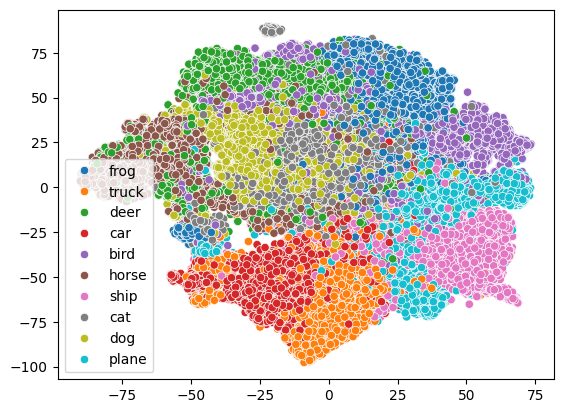

In [39]:
# First reduce the dimension of Moco embeddings via PCA to 128 dimensions
moco_pca = PCA(n_components=128).fit_transform(moco_train_embeddings)
# Then make `moco_embedded` which is a TSNE projection with 2 comonents from the PCA output
moco_embedded = TSNE(n_components=2, perplexity=50, learning_rate='auto', init='random').fit_transform(moco_pca)

moco_class_labels = np.take(np.array(classes), moco_train_labels.int())
sns.scatterplot(x=moco_embedded[:, 0], y=moco_embedded[:, 1], hue=moco_class_labels)

<Axes: >

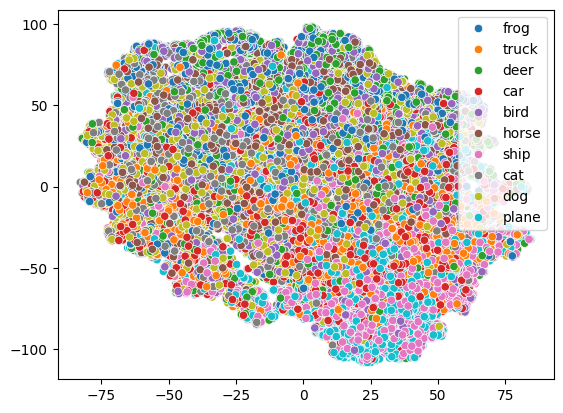

In [40]:
# First reduce the dimension of MAE embeddings via PCA to 128 dimensions
mae_pca = PCA(n_components=128).fit_transform(mae_train_embeddings)
# Then make `mae_embedded` which is a TSNE projection with 2 comonents from the PCA output
mae_embedded = TSNE(n_components=2, perplexity=50, learning_rate='auto', init='random').fit_transform(mae_pca)

mae_class_labels = np.take(np.array(classes), mae_train_labels.int())
sns.scatterplot(x=mae_embedded[:, 0], y=mae_embedded[:, 1], hue=mae_class_labels)